# Homework 2: Machine Learning for Regression

Red Meigen Importante

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `fuel_efficiency_mpg`).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    'data/car_fuel_efficiency_2026.csv',
    usecols=[
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]
)

df.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


## EDA

Look at the fuel_efficiency_mpg variable. Does it have a long tail?

**Answer:** No, it does not have a long tail. In fact, it resembles a normal distribution.

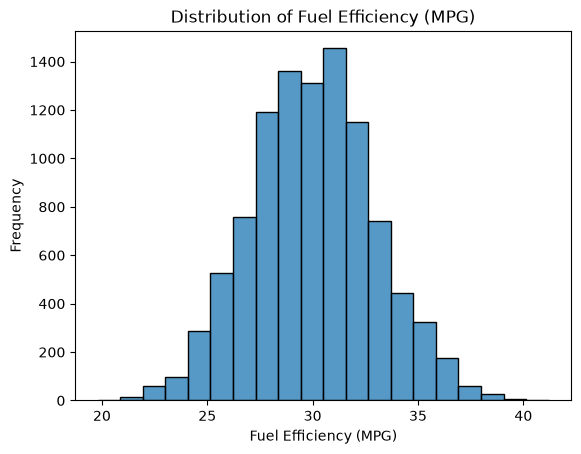

In [5]:
sns.histplot(data=df, x='fuel_efficiency_mpg', bins=20)
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.xlabel('Fuel Efficiency (MPG)')
plt.ylabel('Frequency')
plt.show()

## Question 1

There's one column with missing values. What is it?

In [6]:
df.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

## Question 2

What's the median (50% percentile) for variable 'horsepower'?

In [9]:
df['horsepower'].median()

np.float64(254.0)

## Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

In [ ]:
n = len(df)

# Compute the number of samples for each split
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# For reproducibility
np.random.seed(42)

# Create a shuffled index
idx = np.arange(n)
np.random.shuffle(idx)

# Split based on the shuffled index
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [11]:
df_train.shape, df_val.shape, df_test.shape

((6000, 5), (2000, 5), (2000, 5))

*Note: For Q5, repeat the same block with each listed seed. For Q6, use seed 9.*


## Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

In [ ]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X(df, fill_value):
    return df[features].fillna(fill_value).values

In [ ]:
mean_hp = df_train['horsepower'].mean()


## Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

## Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

## Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?